# 1. Setup & Environment Configuration

In [8]:
# Setup and Imports
import sys
from pathlib import Path

# Add project root to path so src modules can be imported
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import modular project code
from src.data_prep import process_and_save_pipeline
from src.index_calc import calculate_guns_butter_index

# Plotting settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

print(f"Project root resolved to: {PROJECT_ROOT}")

Project root resolved to: C:\Users\JYOTSNA\Documents\fiscal-ledger


# 2. Execute Merge & Index Pipeline

In [9]:
# Run ingestion and index calculations
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_FILE = PROJECT_ROOT / "data" / "processed" / "global_budgets.parquet"

# Run data preparation pipeline
df_merged = process_and_save_pipeline(RAW_DIR, PROCESSED_FILE)

# Compute Guns-vs-Butter index and normalized metrics
df_panel = calculate_guns_butter_index(df_merged)

# Display basic properties
print(f"Dataset Dimensions: {df_panel.shape[0]} rows × {df_panel.shape[1]} columns")
print(f"Unique Countries: {df_panel['Country'].nunique()}")
print(f"Year Range: {df_panel['Year'].min()} – {df_panel['Year'].max()}")
df_panel.head()

Successfully merged 45 countries (3654 rows) into C:\Users\JYOTSNA\Documents\fiscal-ledger\data\processed\global_budgets.parquet
Dataset Dimensions: 3654 rows × 35 columns
Unique Countries: 45
Year Range: 1936 – 2026


,Year,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Total_Budget_Billions_USD,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,Social_Welfare_Percentage,...,Health_Amount_Billions_USD_Calculated,Interest_Payments_Amount_Billions_USD_Calculated,Infrastructure_Amount_Billions_USD_Calculated,Agriculture_Amount_Billions_USD_Calculated,State_Transfers_Amount_Billions_USD_Calculated,Social_Welfare_Amount_Billions_USD_Calculated,Administration_and_Others_Amount_Billions_USD_Calculated,Social_Total_Percentage,Guns_Butter_Ratio,Guns_Butter_Index_Normalized
0,1946,5.78,15.4,17.82,8.65,1.552,13.09,7.85,10.47,10.47,...,0.276566,0.134248,0.203157,0.121832,0.162494,0.162494,0.162494,43.69,0.132296,-0.766323
1,1947,5.78,15.4,17.82,8.65,1.629,13.09,7.85,10.47,10.47,...,0.290288,0.140909,0.213236,0.127877,0.170556,0.170556,0.170556,43.69,0.132296,-0.766323
2,1948,5.78,15.4,17.82,8.65,1.711,13.09,7.85,10.47,10.47,...,0.304900,0.148002,0.223970,0.134314,0.179142,0.179142,0.179142,43.69,0.132296,-0.766323
3,1949,5.78,15.4,17.82,8.65,1.796,13.09,7.85,10.47,10.47,...,0.320047,0.155354,0.235096,0.140986,0.188041,0.188041,0.188041,43.69,0.132296,-0.766323
4,1950,5.78,15.4,17.82,8.65,1.886,13.09,7.85,10.47,10.47,...,0.336085,0.163139,0.246877,0.148051,0.197464,0.197464,0.197464,43.69,0.132296,-0.766323


In [10]:
print(df_panel.columns)

Index(['Year', 'Defense_Percentage', 'Education_Percentage',
       'Health_Percentage', 'Interest_Payments_Percentage',
       'Total_Budget_Billions_USD', 'Infrastructure_Percentage',
       'Agriculture_Percentage', 'State_Transfers_Percentage',
       'Social_Welfare_Percentage', 'Administration_and_Others_Percentage',
       'Defense_Amount_Billions_USD', 'Education_Amount_Billions_USD',
       'Health_Amount_Billions_USD', 'Interest_Payments_Amount_Billions_USD',
       'Infrastructure_Amount_Billions_USD', 'Agriculture_Amount_Billions_USD',
       'State_Transfers_Amount_Billions_USD',
       'Social_Welfare_Amount_Billions_USD',
       'Administration_and_Others_Amount_Billions_USD', 'Country',
       'Total_Percentage_Sum', 'Pct_Discrepancy_Flag',
       'Defense_Amount_Billions_USD_Calculated',
       'Education_Amount_Billions_USD_Calculated',
       'Health_Amount_Billions_USD_Calculated',
       'Interest_Payments_Amount_Billions_USD_Calculated',
       'Infrastructure_Amo

# 3. Data Quality Audit 1 — Percentage Sum Integrity Check
Validate whether budget percentages sum to 100%.

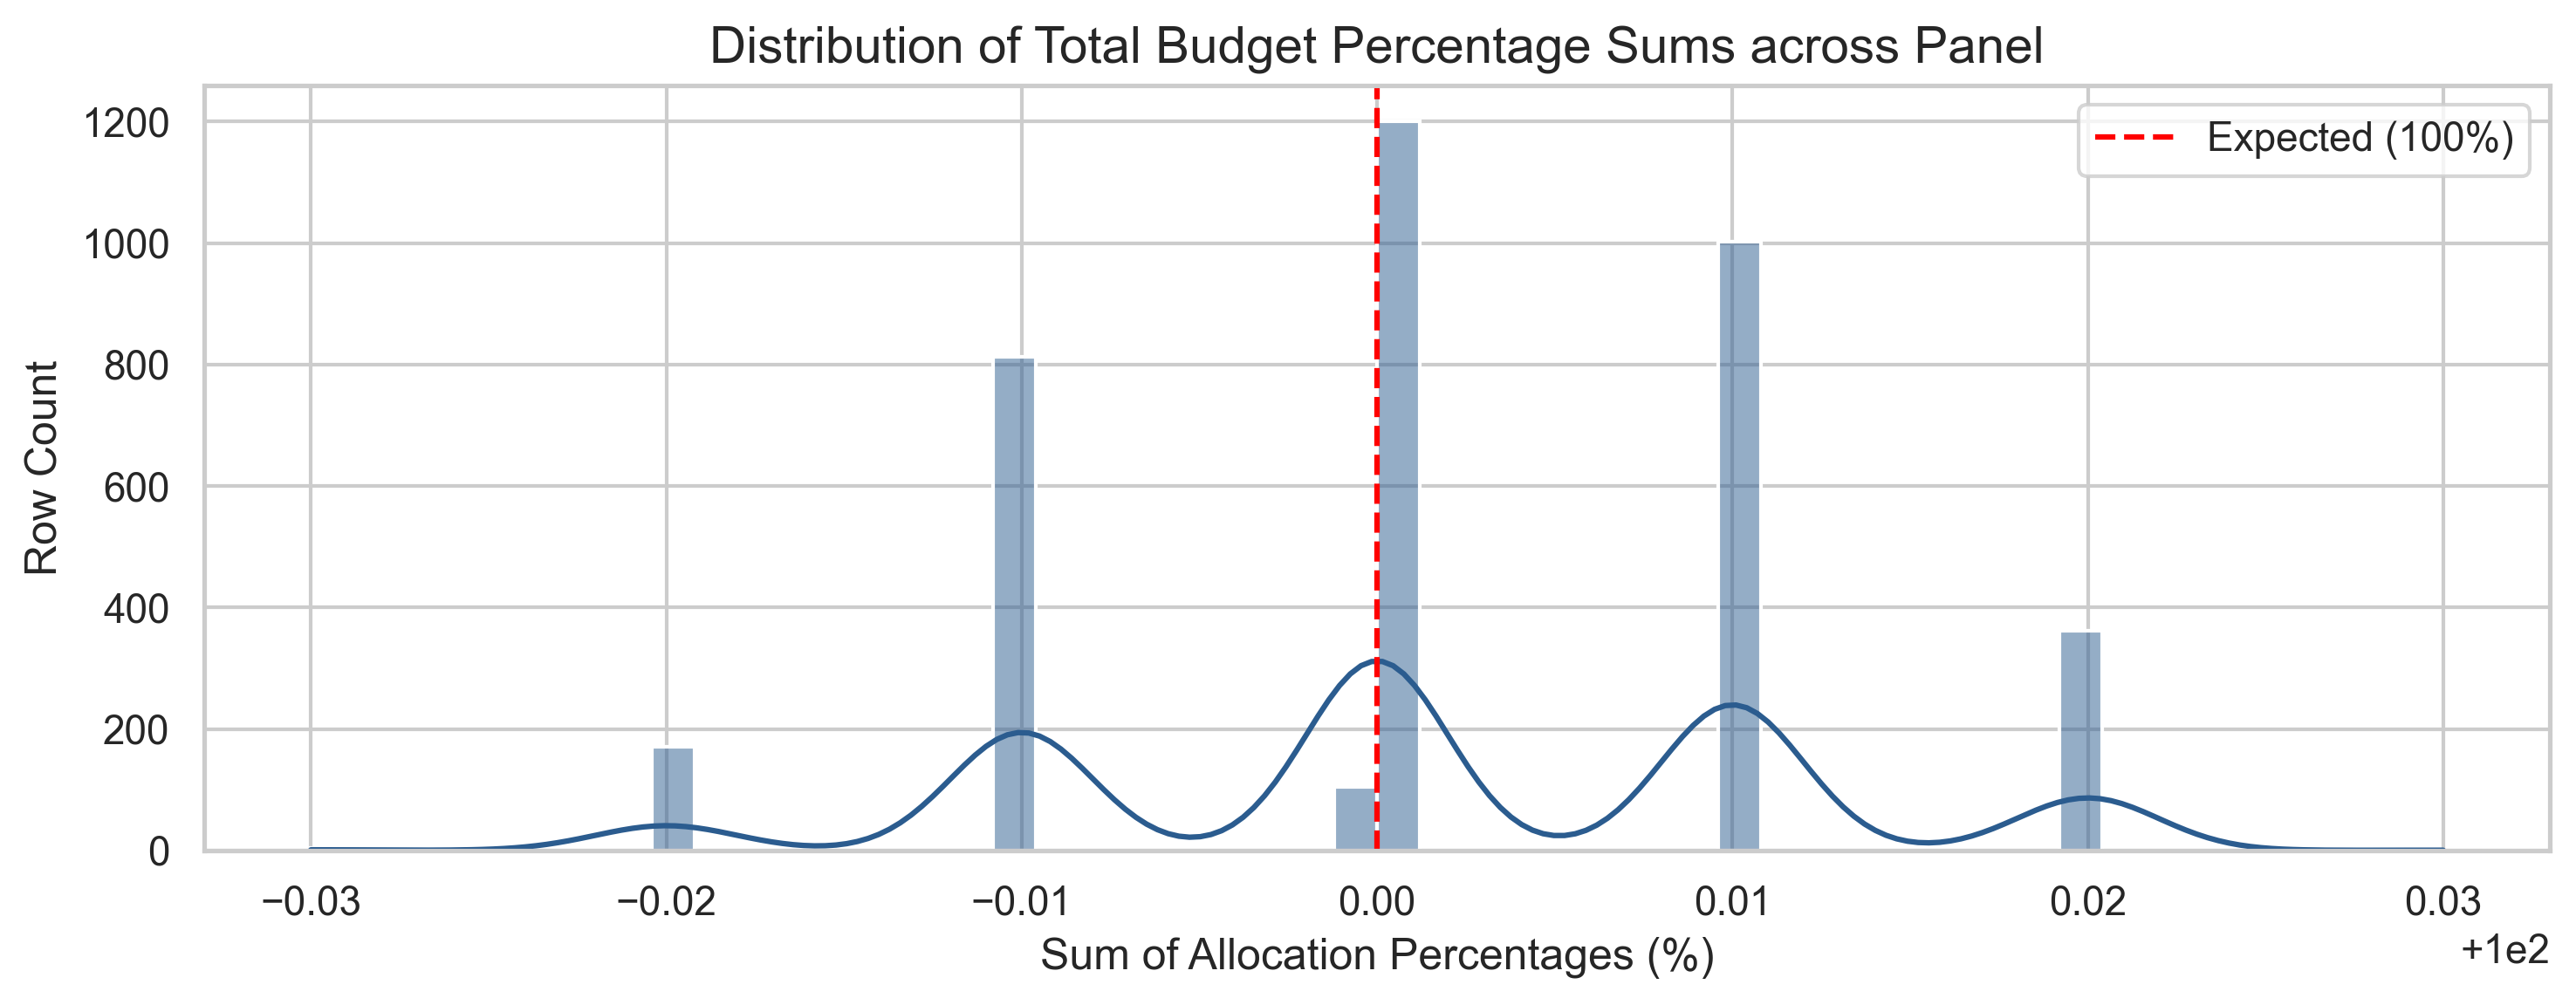

Rows with percentage sum deviation > 1%: 0 (0.00%)


In [11]:
# Audit percentage totals per row
plt.figure(figsize=(10, 4))
sns.histplot(df_panel['Total_Percentage_Sum'], bins=50, kde=True, color='#2b5c8f')

plt.axvline(100.0, color='red', linestyle='--', label='Expected (100%)')
plt.title("Distribution of Total Budget Percentage Sums across Panel", fontsize=14)
plt.xlabel("Sum of Allocation Percentages (%)")
plt.ylabel("Row Count")
plt.legend()
plt.tight_layout()

# Save visual to figures directory
plt.savefig(PROJECT_ROOT / "figures" / "01_pct_sum_distribution.png")
plt.show()

# Print discrepancy statistics
discrepancies = df_panel[df_panel['Pct_Discrepancy_Flag']]
print(f"Rows with percentage sum deviation > 1%: {len(discrepancies)} ({len(discrepancies)/len(df_panel):.2%})")

# 4. Data Quality Audit 2 — Historical Coverage Heatmap
Heatmap of data availability across 1936–2026.

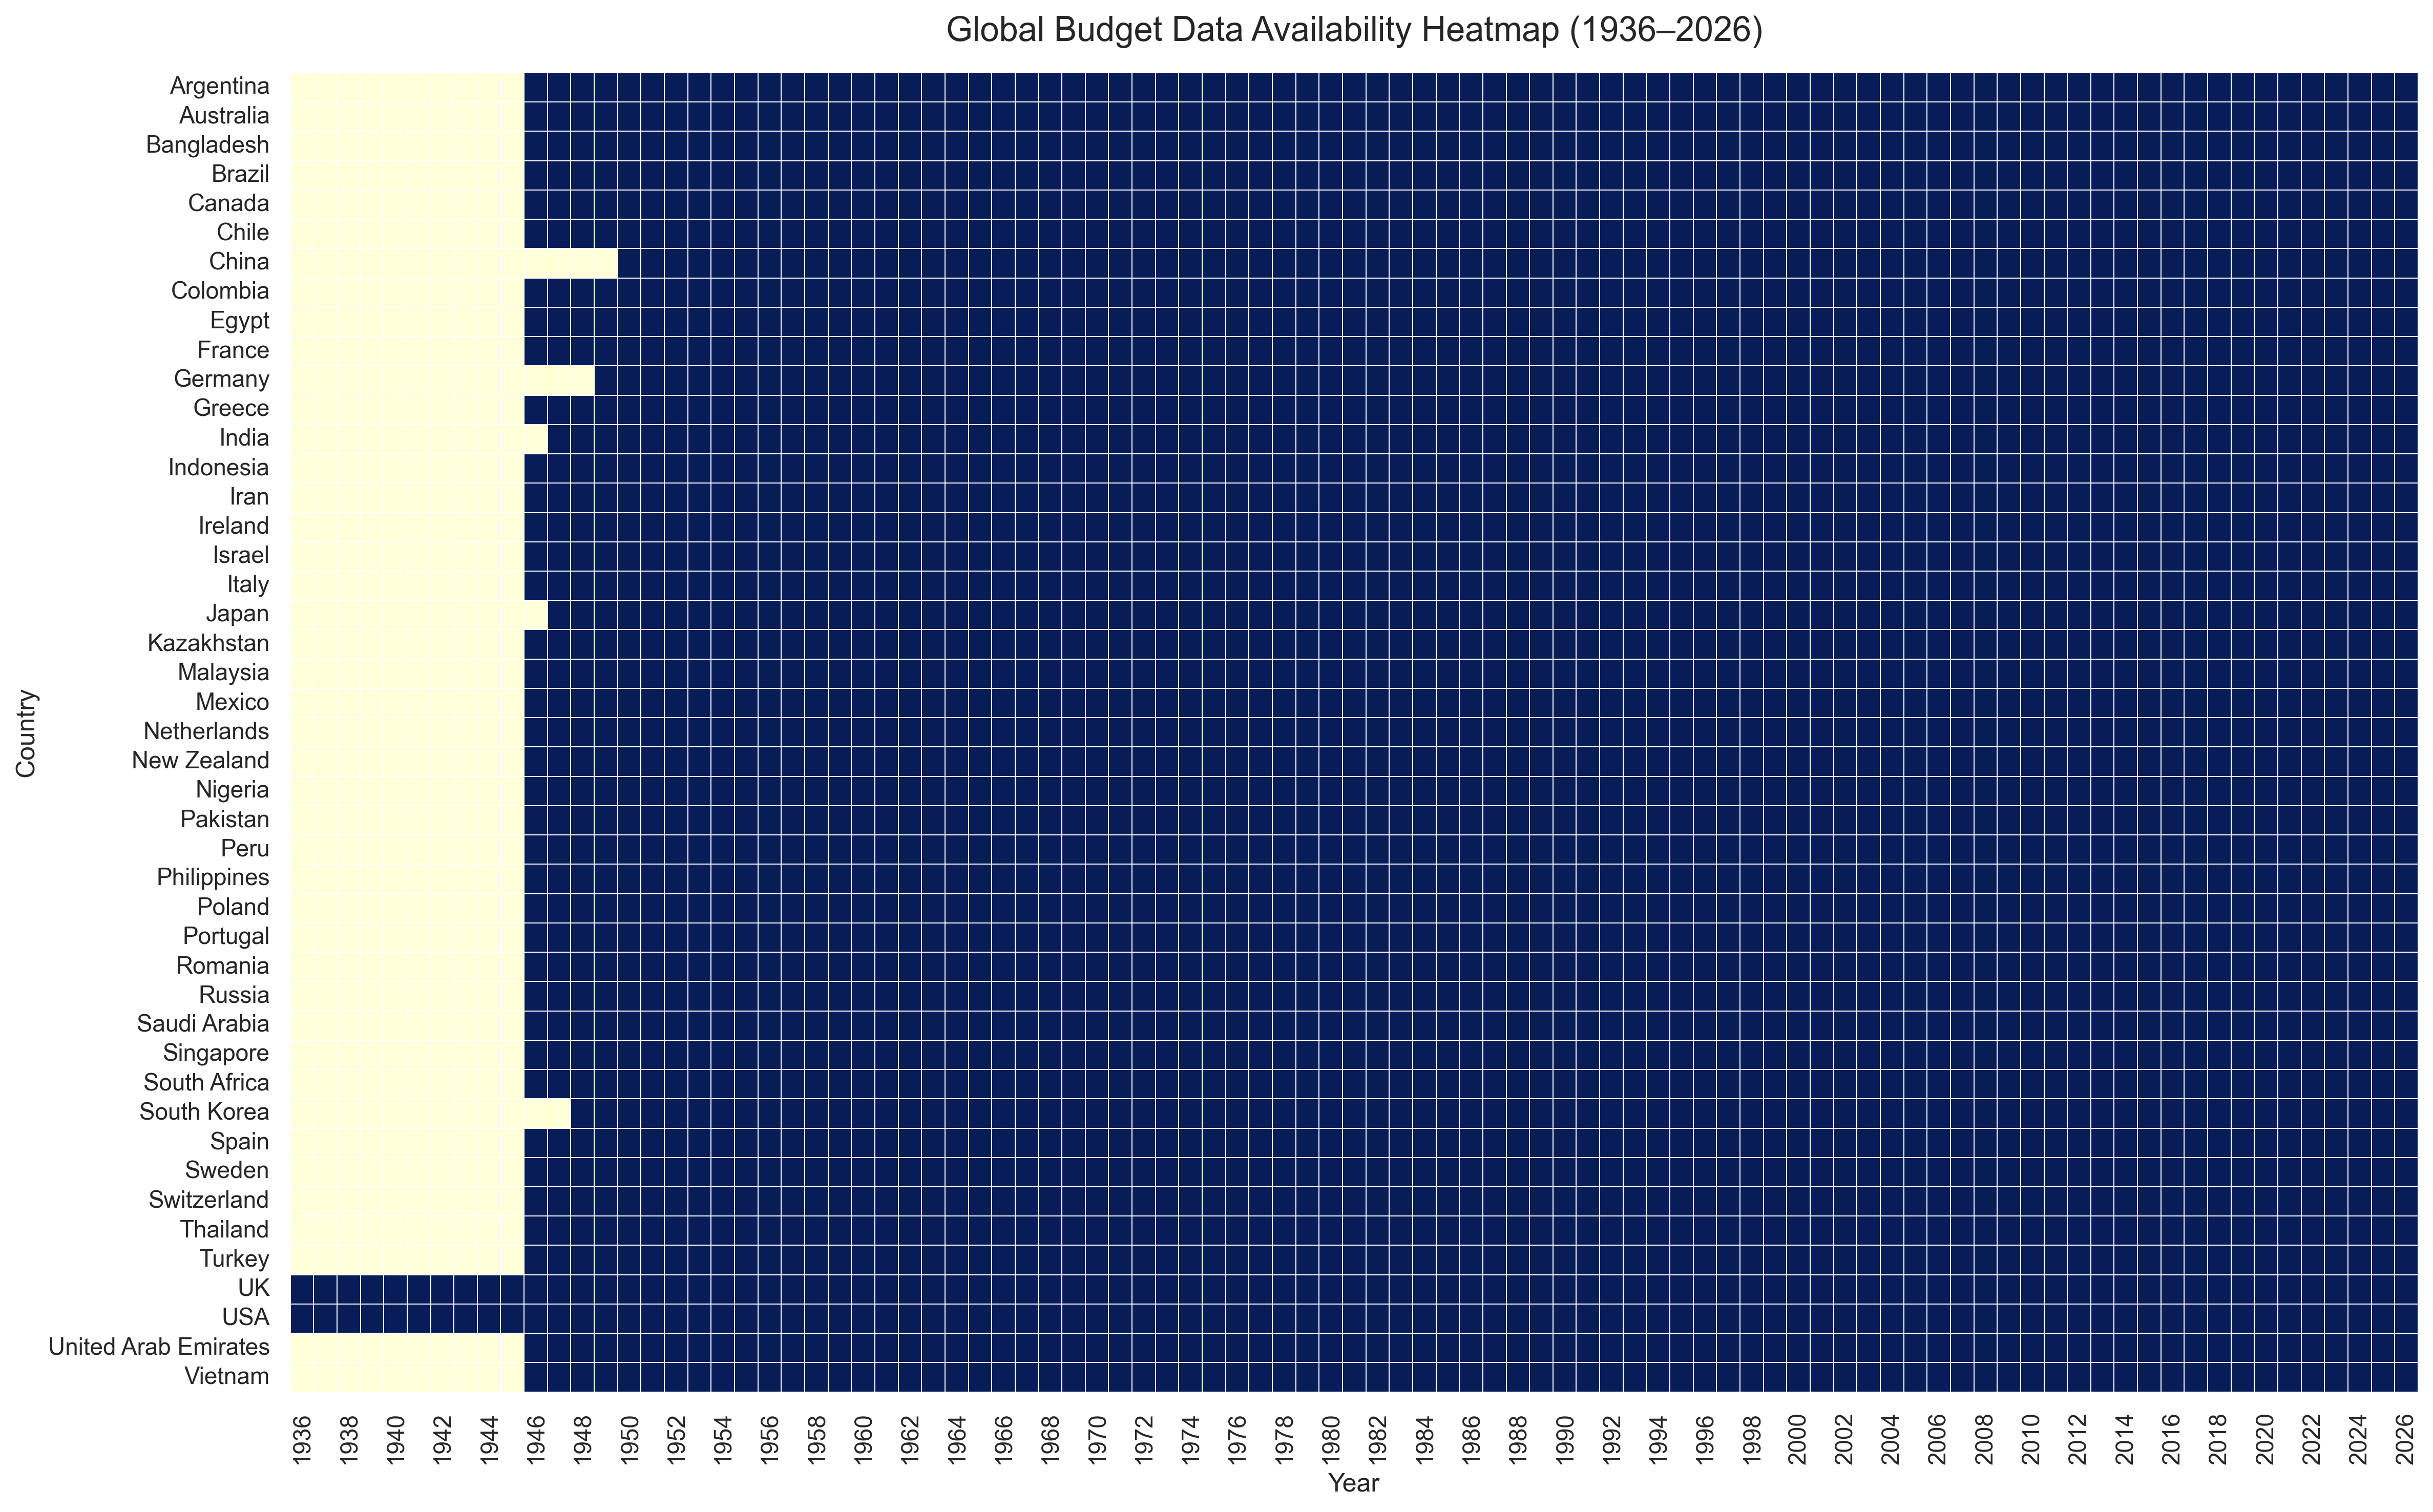

In [12]:
# Data Completeness Audit Heatmap across 1936-2026
coverage_matrix = df_panel.pivot(index='Country', columns='Year', values='Total_Budget_Billions_USD').notnull()

plt.figure(figsize=(16, 10))
sns.heatmap(
    coverage_matrix, 
    cbar=False, 
    cmap="YlGnBu", 
    linewidths=0.1,
    yticklabels=True
)

plt.title("Global Budget Data Availability Heatmap (1936–2026)", fontsize=16, pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.tight_layout()

plt.savefig(PROJECT_ROOT / "figures" / "01_data_coverage_heatmap.png")
plt.show()

# 5.Data Quality Audit 3 — Missingness Summary
Missing Value Analysis: Audit column-level completeness.

In [13]:
# Missing value summary table
missing_summary = pd.DataFrame({
    'Missing_Count': df_panel.isnull().sum(),
    'Missing_Percentage': (df_panel.isnull().sum() / len(df_panel)) * 100
}).sort_values(by='Missing_Percentage', ascending=False)

print("=== Column Missingness Summary ===")
print(missing_summary[missing_summary['Missing_Count'] > 0])

=== Column Missingness Summary ===
Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []


# 6. Export Final Cleaned Parquet File

In [14]:
# Save updated panel dataset with Guns-Butter metrics
FINAL_OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "global_budgets_analyzed.parquet"
df_panel.to_parquet(FINAL_OUTPUT_PATH, index=False)

print(f"Master dataset with Guns-Butter metrics saved to: {FINAL_OUTPUT_PATH}")

Master dataset with Guns-Butter metrics saved to: C:\Users\JYOTSNA\Documents\fiscal-ledger\data\processed\global_budgets_analyzed.parquet
